# Applications of AI

# Final Project

## Diabetes Health Indicators Classification

## Part 1: Exploration & Proposal

### Marianna Kanellaki - S-001081

This notebook covers dataset origin, structure, and relevance, initial exploratory analysis, problem definition, identified challenges and mitigations, and proposed model architectures for diabetes health indicators prediction.

### Dataset Origin

**Dataset:** Diabetes Health Indicators: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

**Origin:** The dataset is hosted on *Kaggle*. The data is sourced from the CDC's Behavioral Risk Factor Surveillance System (BRFSS) and contains health-related survey responses from individuals across the United States.

**Task:** Supervised classification on diabetes risk based on health indicators.

In [132]:
!pip install matplotlib seaborn pandas numpy kagglehub scikit-learn

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import kagglehub
import math
import os

### Dataset Download

In [134]:
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", path)
print("\nFiles in dataset:")
print(os.listdir(path))

Path to dataset files: /home/marianna/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1

Files in dataset:
['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


### Dataset Inspection

In [135]:
df = pd.read_csv(path+"/diabetes_012_health_indicators_BRFSS2015.csv")
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [136]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"\nColumn names:\n{df.columns.tolist()}")

The dataset contains 253680 rows and 22 columns.

Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [137]:
target_col = 'Diabetes_012'
print(f"Target column: {target_col}")
print(f"\nUnique values in target: {sorted(df[target_col].astype(int).unique().tolist())}")

Target column: Diabetes_012

Unique values in target: [0, 1, 2]


The target column is *Diabetes_012*. It contains 3 classes:

| Target Value | Description |
| :---: | :--- |
| **0** | No diabetes (or only during pregnancy) |
| **1** | Prediabetes |
| **2** | Diabetes |

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

All columns were loaded as floats but not all of them are floats. I need to convert some of them, using the descriptions on the dataset page.

In [139]:
# clean types according to kaggle description

boolean_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

categorical_cols = [
    'Diabetes_012',
    'GenHlth',       # 1-5 scale
    'Age',           # 13-level age category
    'Education',     # 1-6 education levels
    'Income'         # 1-8 income brackets
] + boolean_cols # will treat boolean as categorical

integer_cols = [
    'BMI',           # Body Mass Index
    'MentHlth',      # Days of poor mental health in past 30 days
    'PhysHlth'       # Days of poor physical health in past 30 days
]

df[categorical_cols] = df[categorical_cols].astype('category')
df[integer_cols] = df[integer_cols].astype(int)

target = 'Diabetes_012'
cat_features = [col for col in categorical_cols if col != target]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  category
 1   HighBP                253680 non-null  category
 2   HighChol              253680 non-null  category
 3   CholCheck             253680 non-null  category
 4   BMI                   253680 non-null  int64   
 5   Smoker                253680 non-null  category
 6   Stroke                253680 non-null  category
 7   HeartDiseaseorAttack  253680 non-null  category
 8   PhysActivity          253680 non-null  category
 9   Fruits                253680 non-null  category
 10  Veggies               253680 non-null  category
 11  HvyAlcoholConsump     253680 non-null  category
 12  AnyHealthcare         253680 non-null  category
 13  NoDocbcCost           253680 non-null  category
 14  GenHlth               253680 non-null  category

In [140]:
df.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

No null values

In [141]:
df.describe()

,BMI,MentHlth,PhysHlth
count,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081
std,6.608694,7.412847,8.717951
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


### Dataset Structure 

The dataset contains 253,680 health survey responses with 21 health indicators including blood pressure, cholesterol, BMI, smoking status, physical activity, and more. It is formulated as a classification task: predicting whether an individual has diabetes, prediabetes, or no diabetes, based on their health metrics. TODO: add col categories

### EDA

#### Class Distribution

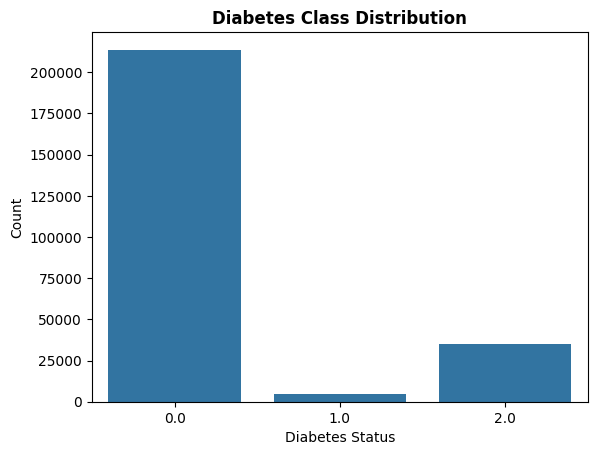

In [142]:
sns.countplot(data=df, x=target_col)
plt.title("Diabetes Class Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.show()

In [143]:
print("\nValue counts in 'Diabetes_012':")
print(df['Diabetes_012'].value_counts())


Value counts in 'Diabetes_012':
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64


The dataset is imbalanced, with the majority of the samples (312,703) belonging to class 0 (no diabetes). Class 2 (diabetes) has only 35,346 cases, while class 1 (pre-diabetes) has even less cases (4,631).

#### Univariate analysis

/tmp/ipykernel_15146/847273167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=axes_cat[idx])
/tmp/ipykernel_15146/847273167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=axes_cat[idx])
/tmp/ipykernel_15146/847273167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=axes_cat[idx])
/tmp/ipykernel_15146/847273167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

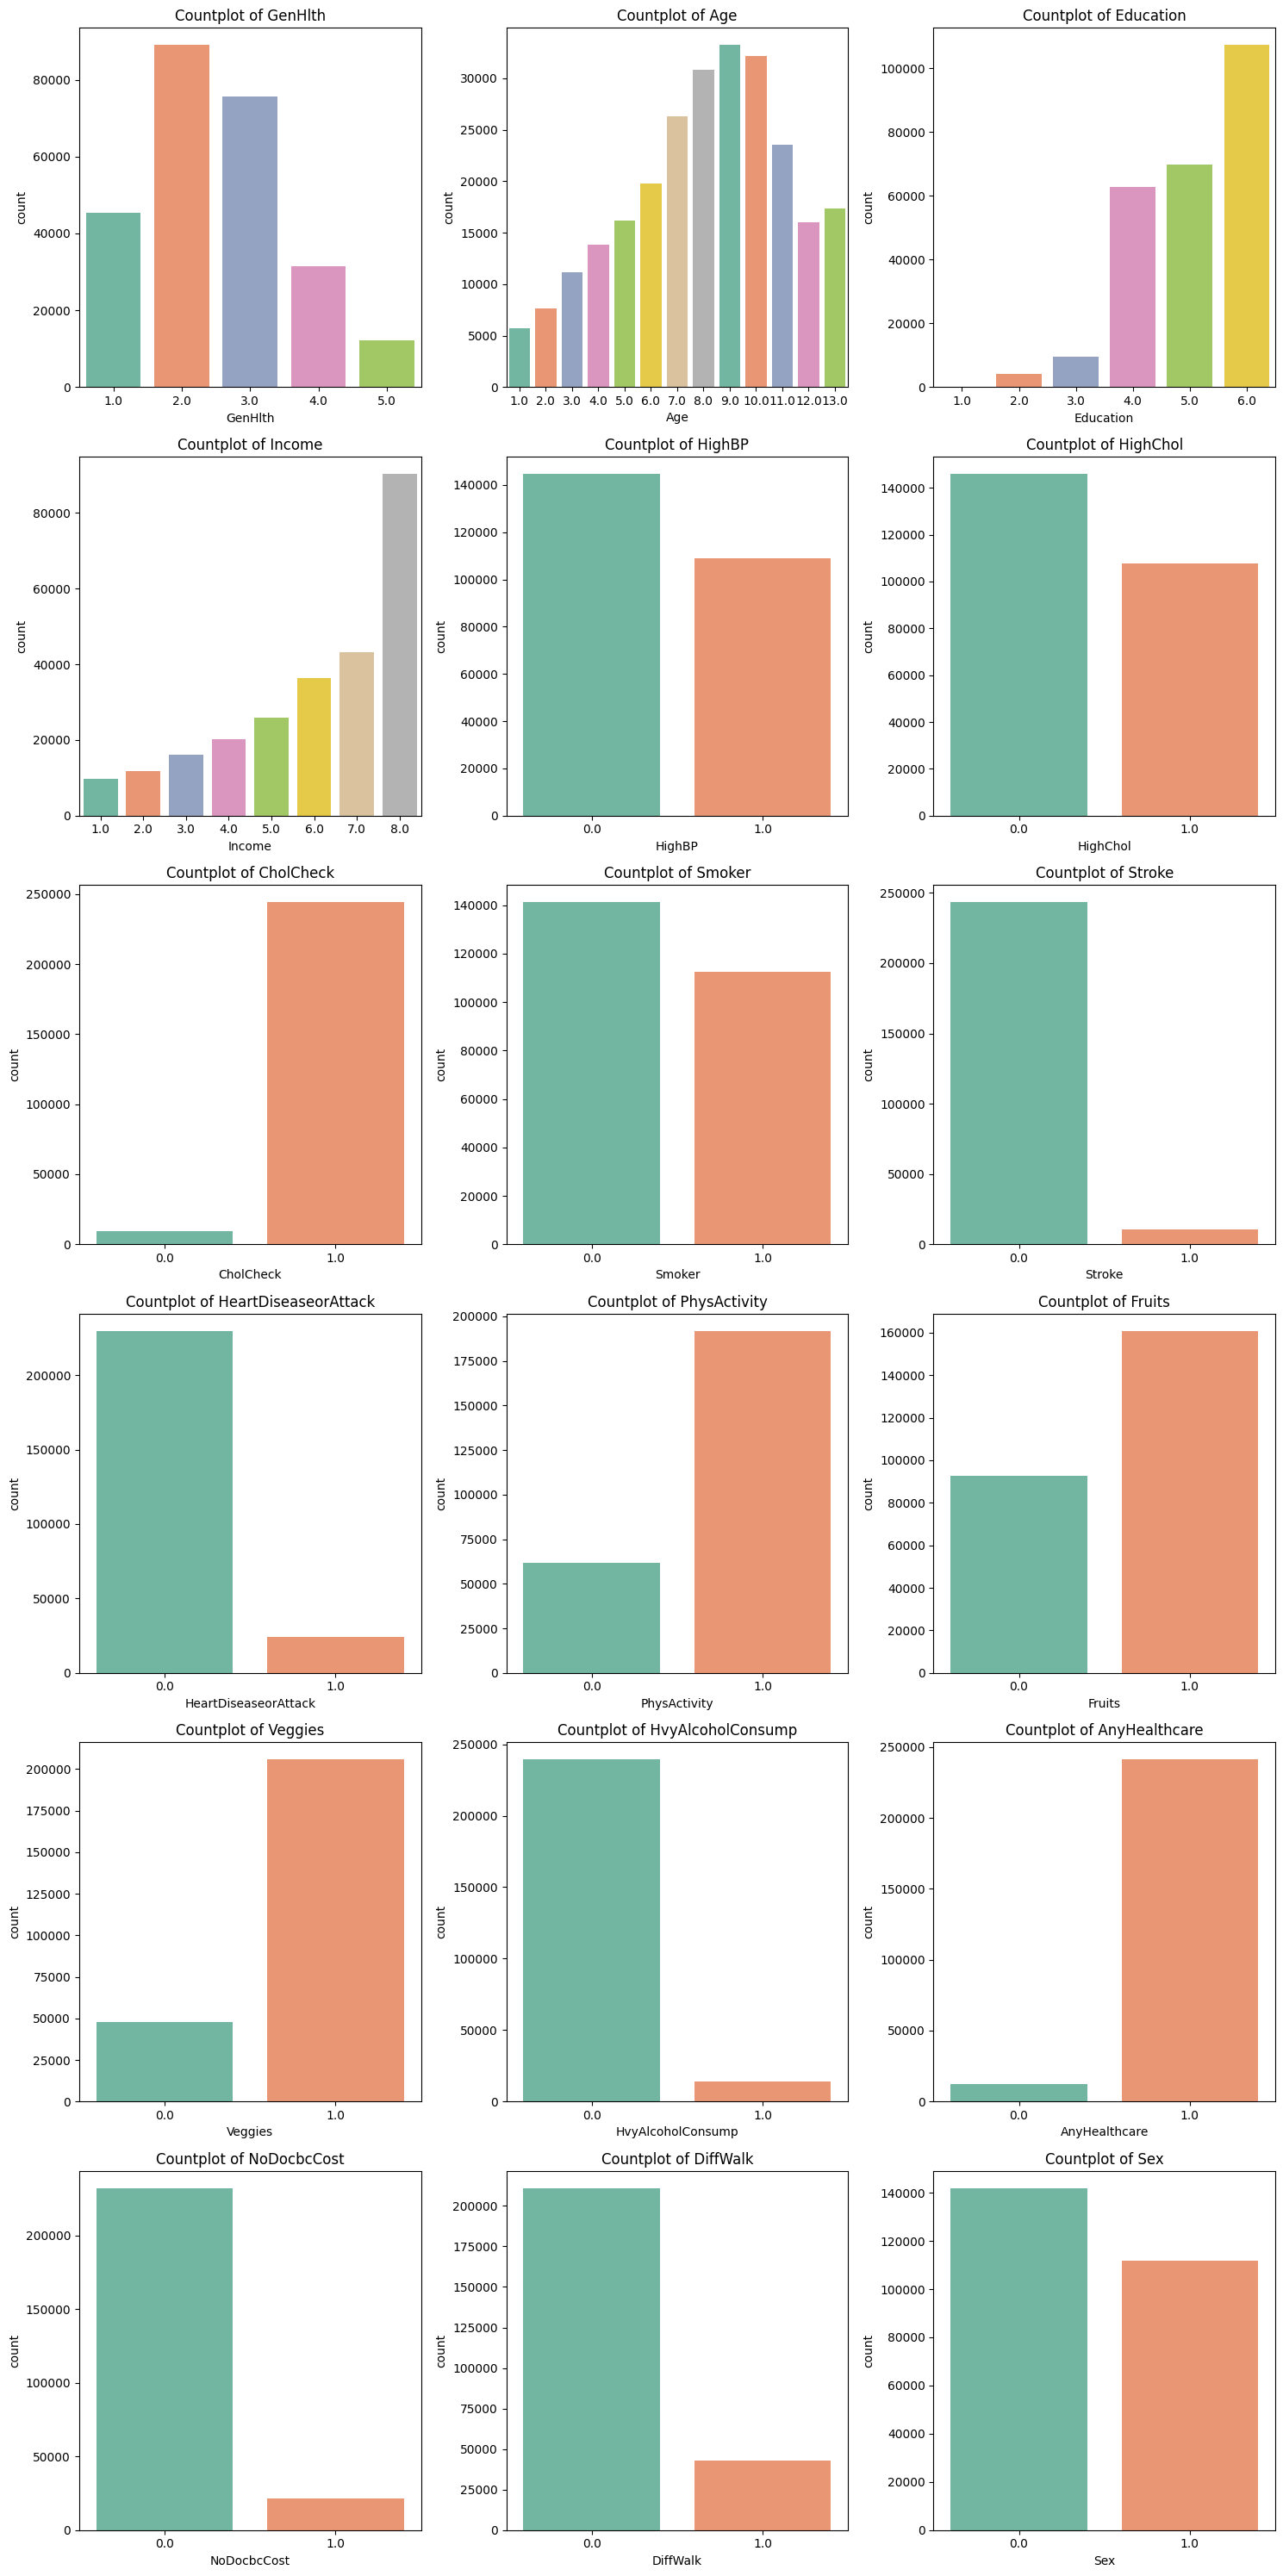

In [144]:
n_cat = len(cat_features)
cols_cat = 3
rows_cat = math.ceil(n_cat / cols_cat)

fig_cat, axes_cat = plt.subplots(rows_cat, cols_cat, figsize=(15, 5 * rows_cat))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, palette='Set2', ax=axes_cat[idx])
    axes_cat[idx].set_title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

##### Demographic Variables:

**Age:** The dataset is heavily left-skewed. The highest frequencies are in brackets 8 through 11, while the youngest brackets (1 through 3) have the lowest representation.

**Socioeconomic Status:** Both *Education* and *Income* are strongly left-skewed. The vast majority of respondents belong to the highest education category (6) and the highest income bracket (8).

**Sex:** Sex shows a more or less balanced distribution, with class 0 (Female) having more samples.

#### Healthcare Access:

The sample population is highly monitored. *CholCheck* and *AnyHealthcare* are overwhelmingly positive (1), and *NoDocbcCost* is overwhelmingly negative (0), indicating high healthcare coverage and low cost barriers.

#### Health issues:

*Stroke*, *HeartDiseaseorAttack*, and *DiffWalk* are dominated by the 0 (negative) class.  *GenHlth* shows a normal slightly right-skewed distribution centered around 2-3.

#### Lifestyle:

The population reports predominantly healthy habits. *Fruits*, *Veggies*, and *PhysActivity* are heavily weighted toward 1. Conversely, *HvyAlcoholConsump* is almost entirely 0.0. However, the *Smoker* feature is balanced, with a few more non-smokers.

#### Health Indicators:

*HighBP* and *HighChol* 's majority is class 0 in both, but there is a very substantial representation of 1 as well.

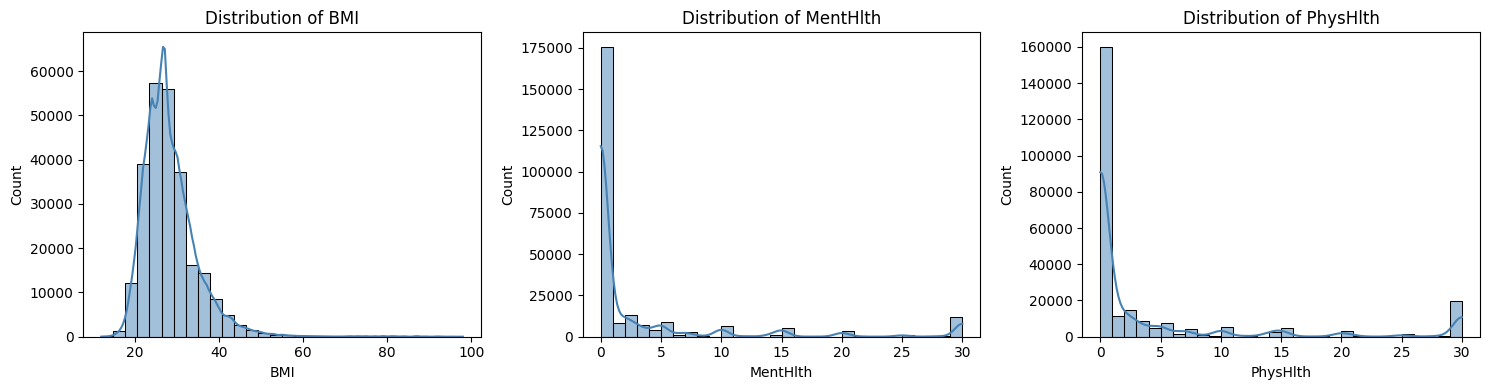

In [145]:
n_num = len(integer_cols)
cols_num = 3
rows_num = math.ceil(n_num / cols_num)

fig_num, axes_num = plt.subplots(rows_num, cols_num, figsize=(15, 4 * rows_num))
axes_num = axes_num.flatten() 

for idx, col in enumerate(integer_cols):
    sns.histplot(data=df, x=col, kde=True, bins=30, color='steelblue', ax=axes_num[idx])
    axes_num[idx].set_title(f'Distribution of {col}')
    axes_num[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

The histograms reveal severe skewness in the continuous health metrics:

- **BMI:** Displays a right-skewed distribution. The highest concentration of respondents falls between 25 and 30. There is a long right tail representing a small amount of individuals with higher BMI values.

- **MentHlth & PhysHlth:** Both distributions share a highly right-skewed shape with the overwhelming majority of people reporting 0 days of poor mental or physical health in the past 30 days. However, there is a notable secondary spike at 30 days in both charts, indicating a population experiencing issues throughout the entire month.

#### Bivariate analysis vs target (diabetes)

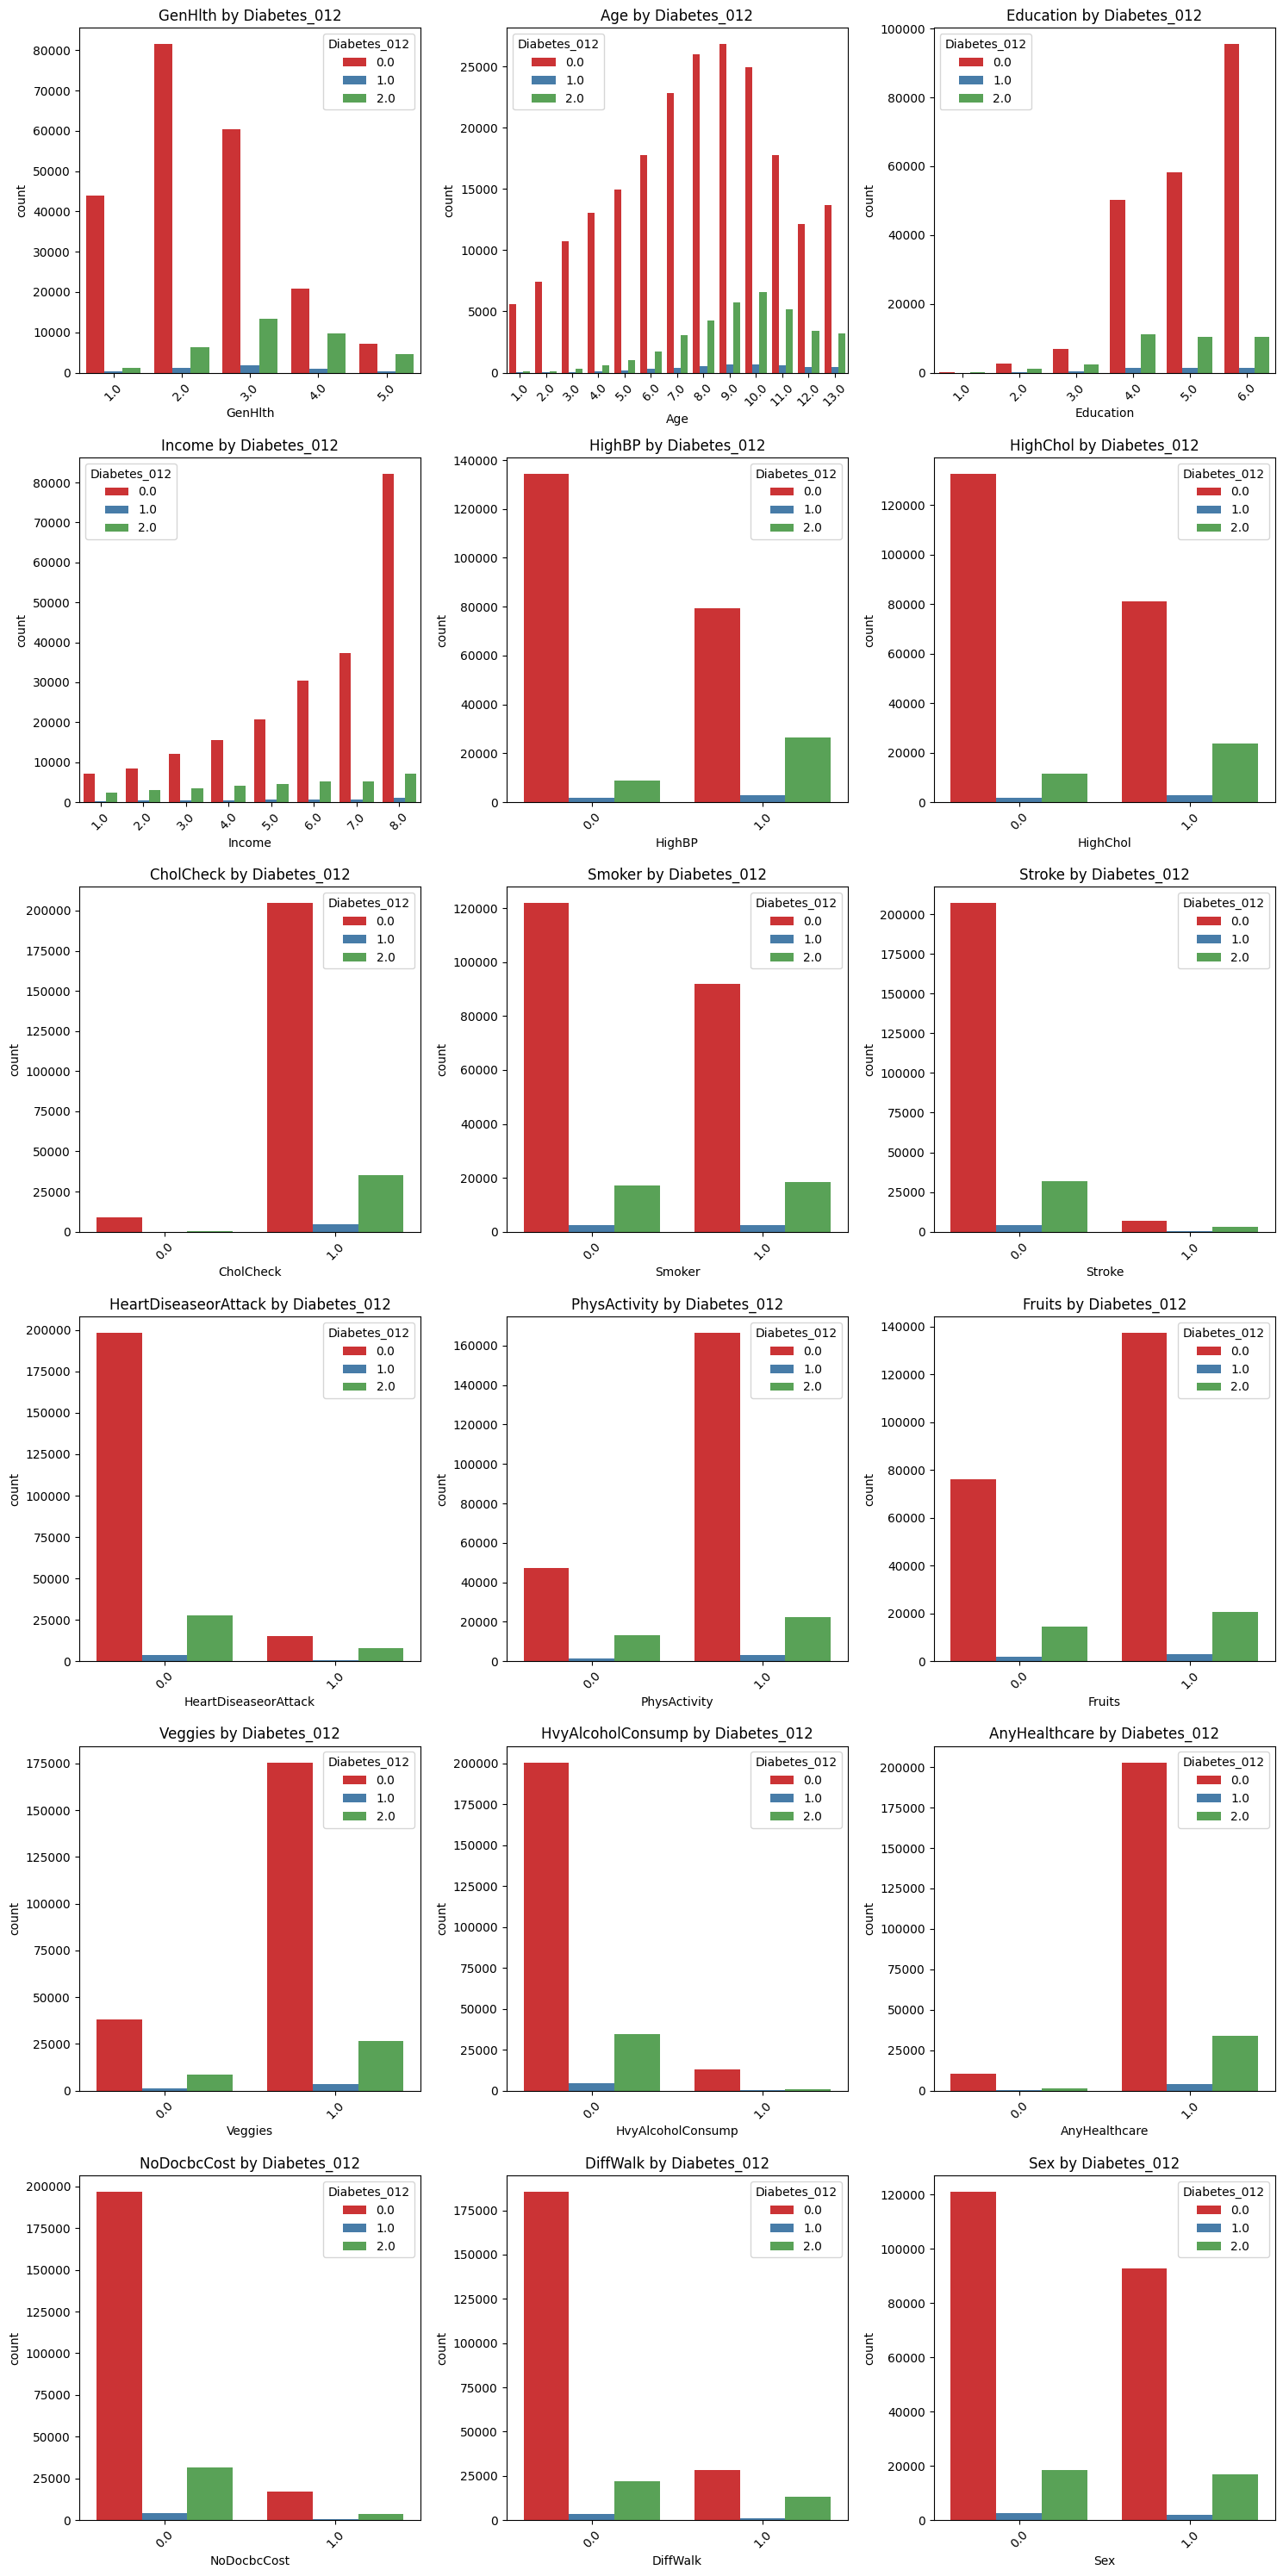

In [146]:
n_cat = len(cat_features)
cols_cat = 3
rows_cat = math.ceil(n_cat / cols_cat)

fig_cat, axes_cat = plt.subplots(rows_cat, cols_cat, figsize=(15, 5 * rows_cat))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue=target, palette='Set1', ax=axes_cat[idx])
    axes_cat[idx].set_title(f'{col} by {target}')
    axes_cat[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### Demographic Variables:

**Age:** The relative proportion of diabetes increases significantly as age increases. The green bars are barely visible in the youngest brackets (1 to 3) but represent a substantial portion of the population in the older brackets (9 to 11).

**Socioeconomic Status:** Both *Education* and *Income* both show a slight negative correlation. In their lower brackets, the green bars make up a visibly larger percentage of the total compared to the highest brackets.

**Sex:** Sex does not seem to affect the presence of diabetes.

#### Healthcare Access:

The sample population is highly monitored. *CholCheck* and *AnyHealthcare* are overwhelmingly positive (1), and *NoDocbcCost* is overwhelmingly negative (0). Because of this lack of variation, these features do not strongly differentiate the target classes on their own. Almost the entirety of the prediabetic and diabetic sub-populations fall into the "covered" and "recently checked" categories.


#### Health issues:

*Stroke*, *HeartDiseaseorAttack*, and *DiffWalk* are dominated by the 0 (negative) class overall. However, the bivariate plots show that among individuals who have these conditions, the relative proportion of diabetes and prediabetes spikes significantly. Furthermore, *GenHlth* shows a severe, direct correlation with the target. As subjective health ratings worsen, the proportion of respondents with prediabetes and diabetes spikes.

#### Lifestyle:

Individuals reporting no physical activity (*PhysActivity*), poor diet (no *Fruits* and *Veggies*), or who are smokers (*Smoker*) show a noticeably higher relative frequency of diabetes. *HvyAlcoholConsump* samples are too few and do not seem to affect the diabetes presence.

#### Health Indicators:

*HighBP* and *HighChol* are massive indicators. Individuals in the positive categories for these features show a tremendous spike in prediabetes and diabetes rates compared to those in the negative categories, highlighting them as strongly correlated risk factors.

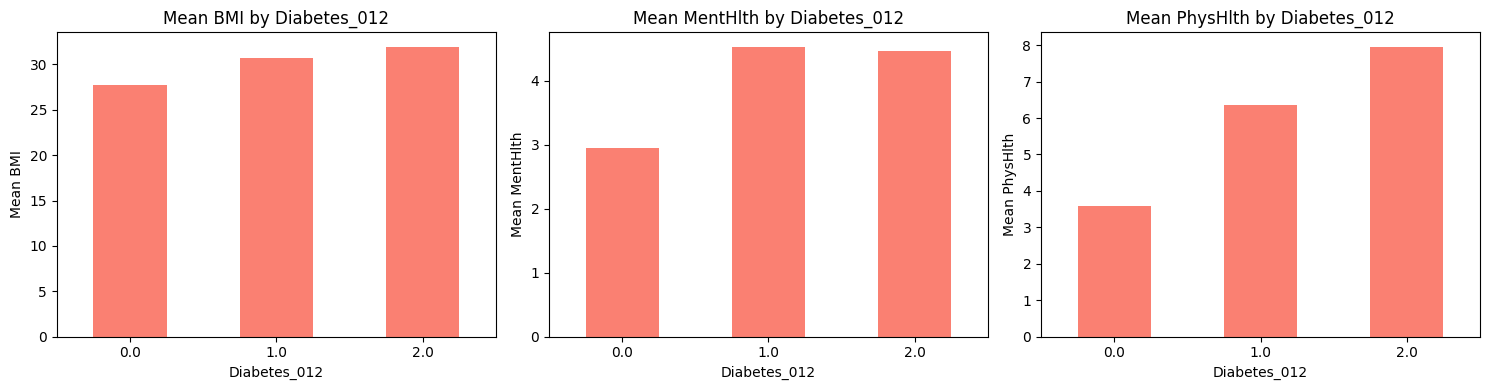

In [147]:
n_num = len(integer_cols)
cols_num = 3
rows_num = math.ceil(n_num / cols_num)

fig_num, axes_num = plt.subplots(rows_num, cols_num, figsize=(15, 4 * rows_num))
axes_num = axes_num.flatten()

for idx, col in enumerate(integer_cols):
    df.groupby(target)[col].mean().plot(kind='bar', color='salmon', ax=axes_num[idx])
    
    axes_num[idx].set_ylabel(f'Mean {col}')
    axes_num[idx].set_title(f'Mean {col} by {target}')
    axes_num[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

All 3 numerical variables show clear, direct relationships between their values and diabetes status. There is an upward trend for all these features. Mean *BMI* is less than 30 for people without diabetes and increases for prediabetics and diabetics. *MeanMentHlth* has an average value of 3 for people without diabetes, increasing to around 4.5 for both prediabetics and diabetics. *PhysHlth* shows the biggest increase, with a mean of 3-4 days for non-diabetics, 6 for pre-diabetics and almost 8 for diabetics. 

**Key Observations:** 
- Individuals with diabetes show higher prevalence of comorbidities (high blood pressure, high cholesterol) and lifestyle risk factors (smoking, lack of physical activity).
- BMI appears to be a significant predictor, with higher BMI values correlating strongly with diabetes diagnosis.
- Age and income levels also show differences between classes, suggesting socioeconomic factors play a role in diabetes risk.
- Binary features (e.g., smoking, exercise) show clear differences in proportions between classes, indicating these health behaviors are important discriminators.

#### Correlation Matrix

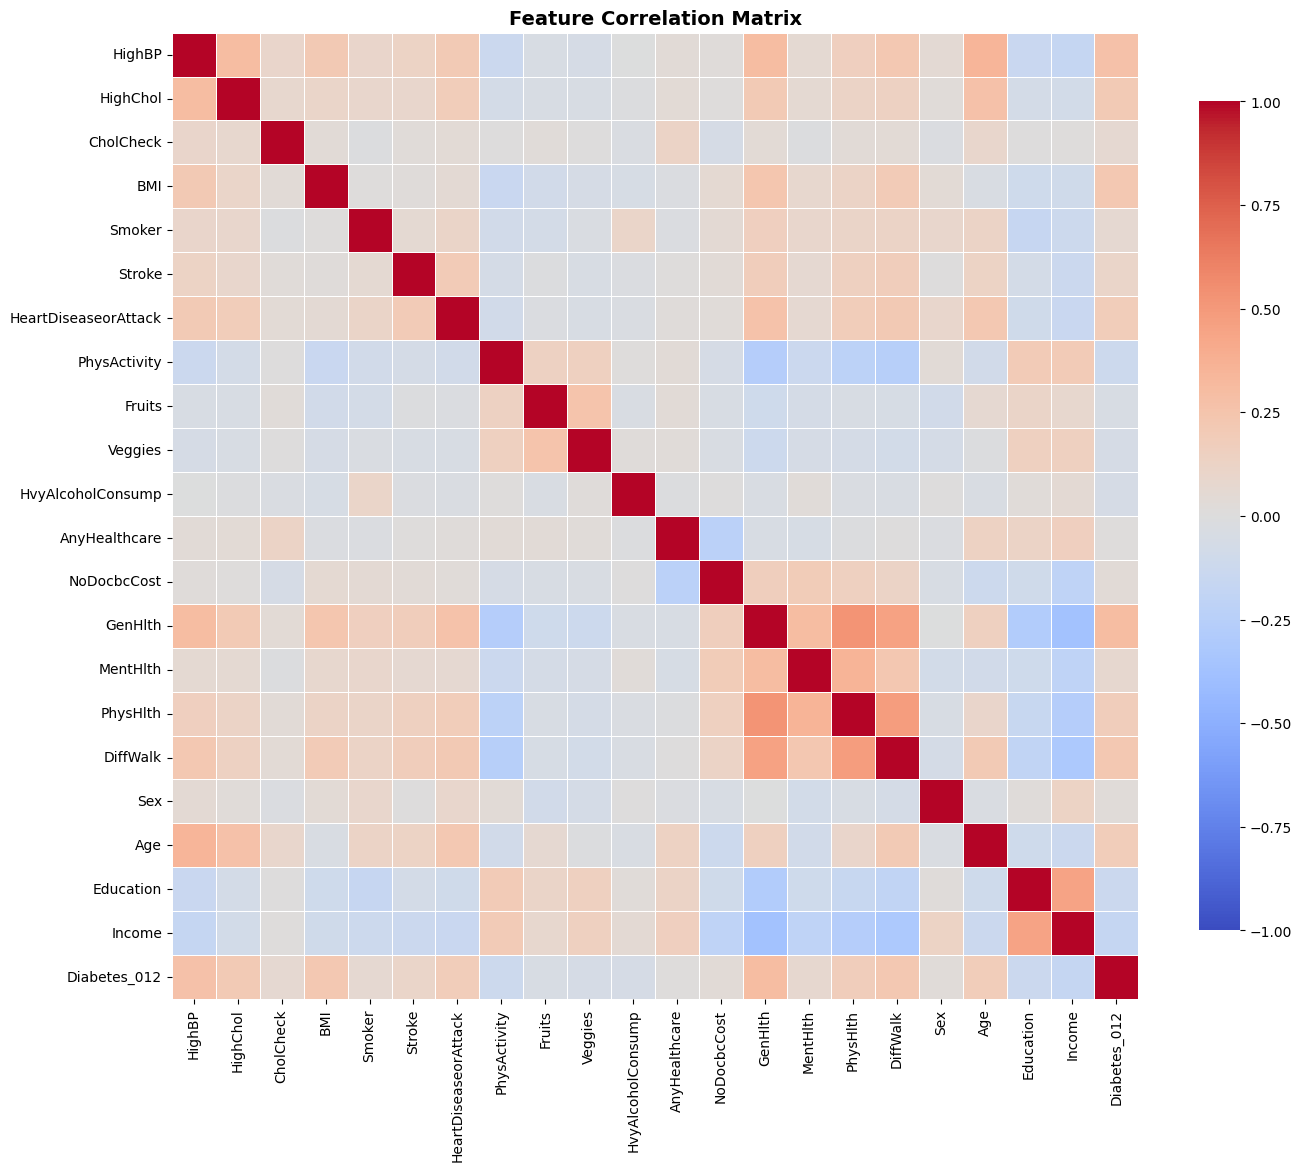

In [148]:
target_col = [col for col in df.columns if 'diabetes' in col.lower()][0]
feature_cols = [col for col in df.columns if 'diabetes' not in col.lower()]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[feature_cols + [target_col]].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Feature Correlation with Diabetes Status

In [149]:
target_corr = corr_matrix['Diabetes_012'].drop('Diabetes_012')
ranked_features = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print("Ranked features correlated with Diabetes:\n")
print(ranked_features)

Ranked features correlated with Diabetes:

GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Income                 -0.171483
Education              -0.130517
PhysActivity           -0.121947
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
Veggies                -0.058972
HvyAlcoholConsump      -0.057882
Fruits                 -0.042192
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Name: Diabetes_012, dtype: float64


#### Top Positive Correlations

These features show the strongest mathematical relationship with an increase in diabetes prevalence:

- *GenHlth (0.30):* This is the strongest single predictor in the dataset. Because the General Health scale ranges from 1 (Excellent) to 5 (Poor), the positive correlation confirms that as individuals report poorer overall health, diabetes prevalence rises significantly.

- *HighBP (0.27) & HighChol (0.21):* These cardiovascular indicators are highly correlated with the target, reinforcing the bivariate visual analysis where prediabetes and diabetes spiked in the positive categories.

- *BMI (0.22):* Shows a moderate/strong positive linear relationship. Higher BMI aligns directly with higher classifications on the diabetes target variable.

- *DiffWalk (0.22):* Difficulty walking acts as a strong indicator for both poor physical health and potentially advanced age or high BMI, correlating closely with diabetes.

- *Age (0.19):* Confirms the visual trend that advancing age brackets map to higher rates of the target condition.

#### Top Negative Correlations

- *Income (-0.17) & Education (-0.13):* Socioeconomic status shows the strongest negative correlation. Individuals in higher income and education brackets have a lower risk of diabetes within this dataset.

- *PhysActivity (-0.12):* Engaging in physical activity inversely correlates with diabetes, representing the strongest lifestyle-based protective factor measured here.

#### Analysis Summary

The exploratory data analysis reveals a distinct profile for diabetes risk within this population, heavily driven by age, subjective health, and co-occurring physical conditions.

The most powerful indicators of diabetes are a poor General Health rating (*GenHlth*), presence of High Blood Pressure (*HighBP*), High Cholesterol (*HighChol*), high *BMI*, and difficulty walking (*DiffWalk*). These features show the highest positive correlations with the target and exhibit massive proportional spikes in the bivariate analysis. *Age* also serves as a primary demographic driver, with diabetes prevalence surging in older brackets.

Socioeconomic and lifestyle factors act as the strongest buffers. Higher *Income*, advanced *Education*, and regular *PhysActivity* demonstrate the strongest negative correlations, meaning individuals in these categories are statistically much less likely to have diabetes.

The dataset contains several features with minimal predictive value for this specific population. Because nearly all respondents report having healthcare coverage, recent cholesterol checks, and no cost barriers to doctors, these variables lack the variance needed to separate the classes. Similarly, dietary metrics (*Fruits*, *Veggies*) and *HvyAlcoholConsump* showed surprisingly weak linear relationships with the target.

### Identified Challenges & Possible Solutions

| Challenge | Impact | Possible Solutions |
|-----------|--------|-----------|
| **Severe Class Imbalance** | The `0` class (No diabetes) vastly outnumbers classes `1` and `2`. Models will likely overpredict `0`, yielding high overall accuracy but terrible recall/F1-scores for actual diabetes cases. | Use SMOTE (oversampling) or apply class weights in the algorithm. |
| **Multicollinearity** | Features like `HighBP`, `HighChol`, `BMI`, and `DiffWalk` are highly correlated with each other. This can make linear models unstable and skew feature importance. | Utilize tree-based models (Random Forest, XGBoost) which handle this naturally, apply L1/L2 Regularization (Lasso/Ridge). |
| **Low-Variance/Noise Variables** | Features like `AnyHealthcare`, `CholCheck`, and `NoDocbcCost` have near-zero correlation because >90% of respondents share the same value. They add computational noise. | Drop features with near-zero correlation to the target. |

### Problem Definition

**Task:** Classification for diabetes

**Input:** 21 behavioral, demographic, and physical health indicators (BMI, blood pressure, cholesterol, smoking status, physical activity, income, etc.)

**Output:** Output: A discrete categorical label representing diabetes status:

    0: No diabetes

    1: Prediabetes

    2: Diabetes

**Objective:** Predict an individual's diabetes risk category based on annual health survey responses, successfully handling the severe class imbalance within the dataset, and compare different methods

**Primary Evaluation Metrics:** Macro F1-score (to account for class imbalance), Per-class Precision & Recall, AUC-ROC

### Architecture Proposal

#### Baseline Model 1 - Binary Logistic Regression
- **Architecture:** Binary Logistic Regression with L2 Regularization (Ridge). 0 no diabetes, 1 diabetes (including pre-diabetes)
- **Pros:** Highly interpretable, trains in seconds, baseline for binary problem
- **Cons:** Cannot capture complex, non-linear interactions between variables

#### Baseline Model 2 - Multi-class Logistic Regression
- **Architecture:** Multinomial Logistic Regression with L2 Regularization (Ridge). Plain, with SMOTE, and with class-weighting
- **Pros:** Highly interpretable, trains in seconds, and provides exact odds ratios for how much each health indicator affects diabetes risk
- **Cons:** Cannot capture complex, non-linear interactions between variables

#### Tree-Based Ensemble - XGBoost
- **Architecture:** Gradient Boosted Trees (XGBoost) optimized for Multiclass classification utilizing sample weighting to counter the dominant '0' class
- **Pros:** Natively handles non-linear interactions, is highly robust to class imbalance, and explicitly maps out feature importance
- **Cons:** Prone to overfitting and is more of a black box compared to linear models

#### Deep Learning - Multi-Layer Perceptron (MLP)
- **Architecture:** Feedforward Neural Network with Batch Normalization, Dropout, and weighted categorical cross-entropy loss
- **Pros:** Captures complex, non-linear patterns, fully utilizes GPU acceleration, serves as the foundational DL benchmark against classical ML
- **Cons:** Demands hyperparameter tuning, feature scaling is mandatory, and requires more computational power to train

#### Deep Learning - TabNet
- **Architecture:** Sequential attention-based neural network designed specifically for tabular data, incorporating sparsity regularization
- **Pros:** Often achieves state-of-the-art performance for DL on tabular data, much more interpretable than a standard MLP
- **Cons:** High computational cost, complex to implement, and requires careful tuning of its attention and sparsity parameters

#### Deep Learning - FT-Transformer
- **Architecture:** Transformer-based architecture that tokenizes both continuous and categorical features into distinct embeddings, utilizing multi-head self-attention to model complex feature interactions
- **Pros:** Represents the cutting edge of tabular deep learning, exceptionally strong at capturing complex interactions across mixed feature types, and directly rivals gradient boosting performance
- **Cons:** Extremely computationally and memory intensive, much slower to train